# Urban Traffic Congestion Prediction

This project uses machine learning to classify urban traffic conditions into Low, Medium, and High congestion levels based on traffic, environmental, and contextual features.

The project includes exploratory data analysis, feature engineering, multiple classification models, time-based evaluation, and a Random Forest model for final predictions.

In [1]:
import pandas as pd

## 1. Load and Understand the Data

In [2]:
df = pd.read_csv("traffic.csv")

df.head()

,Timestamp,Latitude,Longitude,Vehicle_Count,Traffic_Speed_kmh,Road_Occupancy_%,Traffic_Light_State,Weather_Condition,Accident_Report,Sentiment_Score,Ride_Sharing_Demand,Parking_Availability,Emission_Levels_g_km,Energy_Consumption_L_h,Traffic_Condition
0,2024-03-01 00:00:00,40.842275,-73.703149,205,49.893435,82.652780,Yellow,Clear,0,-0.609199,2,45,450.760055,19.574337,High
1,2024-03-01 00:05:00,40.831119,-73.987354,202,22.383965,45.829298,Green,Clear,0,0.965442,16,1,321.800341,5.385554,High
2,2024-03-01 00:10:00,40.819549,-73.732462,252,46.889699,82.772465,Green,Rain,0,0.289660,16,49,231.152655,10.277477,High
3,2024-03-01 00:15:00,40.725849,-73.980134,37,5.730536,37.695567,Red,Fog,0,-0.271965,66,10,410.384292,29.243279,High
4,2024-03-01 00:20:00,40.813265,-73.961631,64,61.348034,22.313358,Red,Snow,0,-0.797606,3,5,364.466342,16.801459,Low


In [3]:
df.shape

(5000, 15)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Timestamp               5000 non-null   str    
 1   Latitude                5000 non-null   float64
 2   Longitude               5000 non-null   float64
 3   Vehicle_Count           5000 non-null   int64  
 4   Traffic_Speed_kmh       5000 non-null   float64
 5   Road_Occupancy_%        5000 non-null   float64
 6   Traffic_Light_State     5000 non-null   str    
 7   Weather_Condition       5000 non-null   str    
 8   Accident_Report         5000 non-null   int64  
 9   Sentiment_Score         5000 non-null   float64
 10  Ride_Sharing_Demand     5000 non-null   int64  
 11  Parking_Availability    5000 non-null   int64  
 12  Emission_Levels_g_km    5000 non-null   float64
 13  Energy_Consumption_L_h  5000 non-null   float64
 14  Traffic_Condition       5000 non-null   str    
dty

In [5]:
df.describe()

,Latitude,Longitude,Vehicle_Count,Traffic_Speed_kmh,Road_Occupancy_%,Accident_Report,Sentiment_Score,Ride_Sharing_Demand,Parking_Availability,Emission_Levels_g_km,Energy_Consumption_L_h
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,40.749645,-73.847433,153.921200,42.111096,54.748397,0.096000,-0.005652,50.487800,24.613000,272.174927,17.343243
std,0.086123,0.086204,83.523342,21.707720,26.145238,0.294621,0.583790,28.484426,14.532511,130.086372,7.208277
min,40.600016,-73.999987,10.000000,5.002789,10.005031,0.000000,-0.999819,1.000000,0.000000,50.136855,5.003787
25%,40.675403,-73.920281,80.000000,23.195752,32.089653,0.000000,-0.500154,26.000000,12.000000,160.564433,11.098761
50%,40.748875,-73.846058,156.000000,42.191599,54.657297,0.000000,-0.010564,50.000000,24.000000,272.045513,17.153791
75%,40.824735,-73.771685,226.000000,60.751760,77.581720,0.000000,0.500518,75.000000,37.000000,382.242055,23.516595
max,40.899972,-73.700159,299.000000,79.997556,99.999729,1.000000,0.999354,99.000000,49.000000,499.922663,29.995416


In [6]:
df["Traffic_Condition"].value_counts()

Traffic_Condition
High      3166
Medium    1475
Low        359
Name: count, dtype: int64

In [7]:
df.columns

Index(['Timestamp', 'Latitude', 'Longitude', 'Vehicle_Count',
       'Traffic_Speed_kmh', 'Road_Occupancy_%', 'Traffic_Light_State',
       'Weather_Condition', 'Accident_Report', 'Sentiment_Score',
       'Ride_Sharing_Demand', 'Parking_Availability', 'Emission_Levels_g_km',
       'Energy_Consumption_L_h', 'Traffic_Condition'],
      dtype='str')

In [8]:
df.isnull().sum()

Timestamp                 0
Latitude                  0
Longitude                 0
Vehicle_Count             0
Traffic_Speed_kmh         0
Road_Occupancy_%          0
Traffic_Light_State       0
Weather_Condition         0
Accident_Report           0
Sentiment_Score           0
Ride_Sharing_Demand       0
Parking_Availability      0
Emission_Levels_g_km      0
Energy_Consumption_L_h    0
Traffic_Condition         0
dtype: int64

In [9]:
df.dtypes

Timestamp                     str
Latitude                  float64
Longitude                 float64
Vehicle_Count               int64
Traffic_Speed_kmh         float64
Road_Occupancy_%          float64
Traffic_Light_State           str
Weather_Condition             str
Accident_Report             int64
Sentiment_Score           float64
Ride_Sharing_Demand         int64
Parking_Availability        int64
Emission_Levels_g_km      float64
Energy_Consumption_L_h    float64
Traffic_Condition             str
dtype: object

In [10]:
df["Traffic_Condition"].unique()

<ArrowStringArray>
['High', 'Low', 'Medium']
Length: 3, dtype: str

In [11]:
df.duplicated().sum()

np.int64(0)

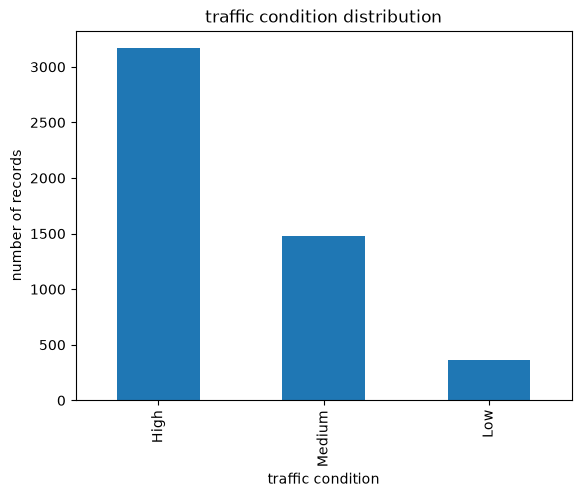

In [12]:
import matplotlib.pyplot as plt

df["Traffic_Condition"].value_counts().plot(kind="bar")
plt.xlabel("traffic condition")
plt.ylabel("number of records")
plt.title("traffic condition distribution")

plt.show()

In [13]:
df.groupby("Traffic_Condition")["Vehicle_Count"].mean()

Traffic_Condition
High      182.492419
Low        53.389972
Medium    117.063051
Name: Vehicle_Count, dtype: float64

In [14]:
df.groupby("Traffic_Condition")["Traffic_Speed_kmh"].mean()

Traffic_Condition
High      37.865941
Low       59.875717
Medium    46.899342
Name: Traffic_Speed_kmh, dtype: float64

## 2. Exploratory Data Analysis

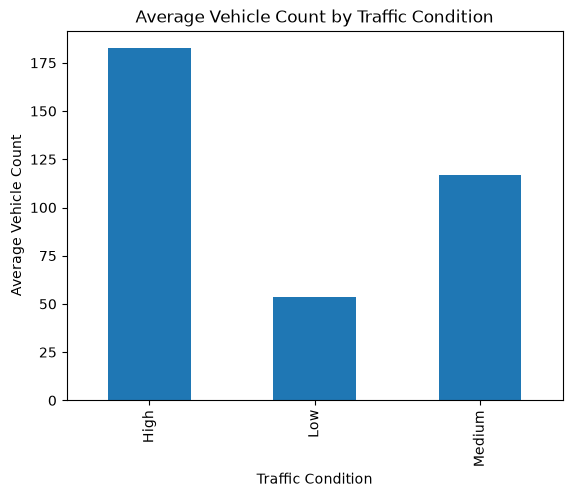

In [15]:
df.groupby("Traffic_Condition")["Vehicle_Count"].mean().plot(kind="bar")

plt.xlabel("Traffic Condition")
plt.ylabel("Average Vehicle Count")
plt.title("Average Vehicle Count by Traffic Condition")

plt.show()

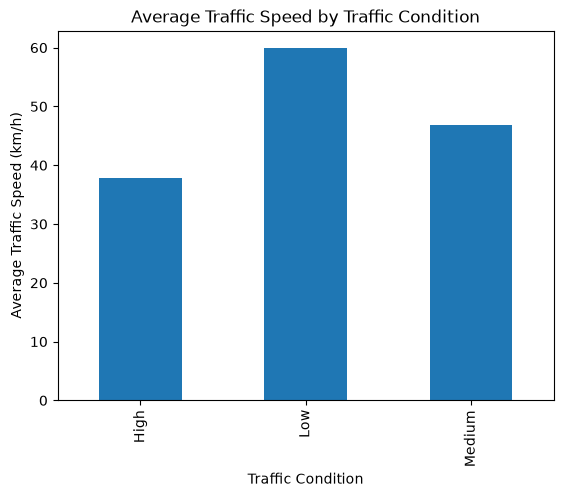

In [16]:
df.groupby("Traffic_Condition")["Traffic_Speed_kmh"].mean().plot(kind="bar")

plt.xlabel("Traffic Condition")
plt.ylabel("Average Traffic Speed (km/h)")
plt.title("Average Traffic Speed by Traffic Condition")

plt.show()

In [17]:
pd.crosstab(df["Weather_Condition"], df["Traffic_Condition"])

Traffic_Condition,High,Low,Medium
Weather_Condition,,,
Clear,754,74,391
Fog,807,84,354
Rain,811,91,377
Snow,794,110,353


In [18]:
pd.crosstab(df["Traffic_Light_State"],df["Traffic_Condition"])

Traffic_Condition,High,Low,Medium
Traffic_Light_State,,,
Green,1047,113,491
Red,1013,114,496
Yellow,1106,132,488


In [19]:
df.groupby("Traffic_Condition")["Accident_Report"].mean()

Traffic_Condition
High      0.151611
Low       0.000000
Medium    0.000000
Name: Accident_Report, dtype: float64

In [20]:
df.groupby("Traffic_Condition")["Road_Occupancy_%"].mean()


Traffic_Condition
High      60.679654
Low       29.536599
Medium    48.153600
Name: Road_Occupancy_%, dtype: float64

In [21]:
df.groupby("Traffic_Condition")["Ride_Sharing_Demand"].mean()

Traffic_Condition
High      50.786481
Low       50.158774
Medium    49.926780
Name: Ride_Sharing_Demand, dtype: float64

In [22]:
df.groupby("Traffic_Condition")["Parking_Availability"].mean()

Traffic_Condition
High      24.615287
Low       23.395543
Medium    24.904407
Name: Parking_Availability, dtype: float64

In [23]:
df.groupby("Traffic_Condition")["Emission_Levels_g_km"].mean()

Traffic_Condition
High      274.448158
Low       262.143258
Medium    269.737178
Name: Emission_Levels_g_km, dtype: float64

In [24]:
df.groupby("Traffic_Condition")["Energy_Consumption_L_h"].mean()

Traffic_Condition
High      17.227611
Low       17.533083
Medium    17.545237
Name: Energy_Consumption_L_h, dtype: float64

In [25]:
df.corr(numeric_only=True)

,Latitude,Longitude,Vehicle_Count,Traffic_Speed_kmh,Road_Occupancy_%,Accident_Report,Sentiment_Score,Ride_Sharing_Demand,Parking_Availability,Emission_Levels_g_km,Energy_Consumption_L_h
Latitude,1.000000,-0.003971,0.007470,0.005284,0.011346,-0.011874,0.001996,0.000400,0.006585,0.008914,-0.021324
Longitude,-0.003971,1.000000,0.014853,-0.012327,0.011606,0.012598,-0.014923,0.007059,0.008788,0.010227,0.030253
Vehicle_Count,0.007470,0.014853,1.000000,-0.003474,0.031420,-0.010773,-0.001953,-0.009880,0.003478,0.006750,-0.019133
Traffic_Speed_kmh,0.005284,-0.012327,-0.003474,1.000000,-0.012365,0.002304,0.010456,-0.018285,-0.010029,-0.006471,-0.013124
Road_Occupancy_%,0.011346,0.011606,0.031420,-0.012365,1.000000,-0.005890,0.014893,-0.004037,-0.023494,0.003363,0.005441
Accident_Report,-0.011874,0.012598,-0.010773,0.002304,-0.005890,1.000000,-0.001217,-0.003055,0.011435,0.015613,0.008363
Sentiment_Score,0.001996,-0.014923,-0.001953,0.010456,0.014893,-0.001217,1.000000,0.004813,-0.012311,-0.015449,0.007166
Ride_Sharing_Demand,0.000400,0.007059,-0.009880,-0.018285,-0.004037,-0.003055,0.004813,1.000000,0.000792,-0.001670,0.012391
Parking_Availability,0.006585,0.008788,0.003478,-0.010029,-0.023494,0.011435,-0.012311,0.000792,1.000000,0.013500,-0.010631
Emission_Levels_g_km,0.008914,0.010227,0.006750,-0.006471,0.003363,0.015613,-0.015449,-0.001670,0.013500,1.000000,-0.015695


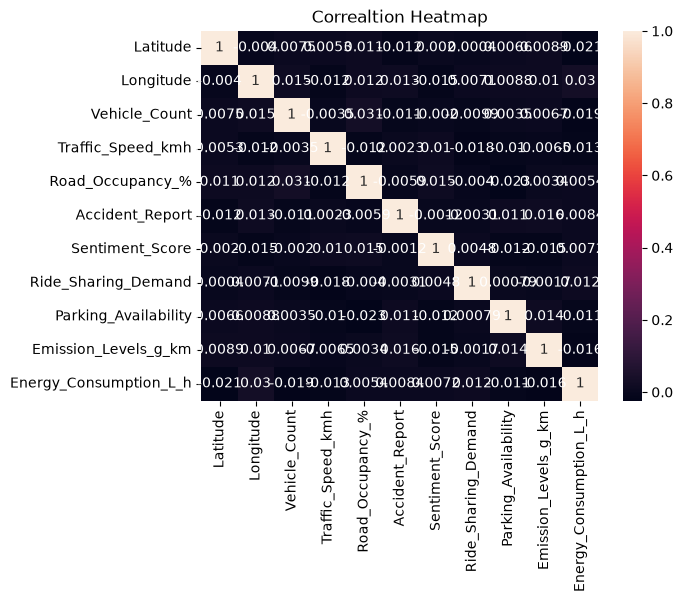

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation=df.corr(numeric_only=True)

sns.heatmap(correlation,annot=True)

plt.title("Correaltion Heatmap")
plt.show()

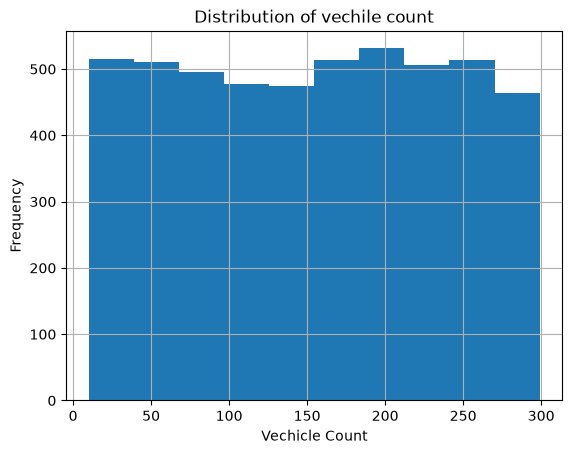

In [27]:
df["Vehicle_Count"].hist()

plt.xlabel("Vechicle Count")
plt.ylabel("Frequency")
plt.title("Distribution of vechile count")

plt.show()

In [28]:
df["Timestamp"].head()


0    2024-03-01 00:00:00
1    2024-03-01 00:05:00
2    2024-03-01 00:10:00
3    2024-03-01 00:15:00
4    2024-03-01 00:20:00
Name: Timestamp, dtype: str

In [29]:
df["Timestamp"]=pd.to_datetime(df["Timestamp"])


In [30]:
df["Timestamp"].dtype

dtype('<M8[us]')

In [31]:
df["Hour"] = df["Timestamp"].dt.hour
df[["Timestamp", "Hour"]].head(10)

,Timestamp,Hour
0,2024-03-01 00:00:00,0
1,2024-03-01 00:05:00,0
2,2024-03-01 00:10:00,0
3,2024-03-01 00:15:00,0
4,2024-03-01 00:20:00,0
5,2024-03-01 00:25:00,0
6,2024-03-01 00:30:00,0
7,2024-03-01 00:35:00,0
8,2024-03-01 00:40:00,0
9,2024-03-01 00:45:00,0


In [32]:
df.groupby("Hour")["Vehicle_Count"].mean()

Hour
0     145.916667
1     160.694444
2     155.902778
3     159.449074
4     152.652778
5     158.273148
6     153.398148
7     153.773148
8     156.485849
9     142.852941
10    162.862745
11    151.676471
12    152.647059
13    153.573529
14    147.588235
15    145.024510
16    154.500000
17    156.960784
18    155.906863
19    171.132353
20    152.073529
21    151.803922
22    151.372549
23    146.975490
Name: Vehicle_Count, dtype: float64

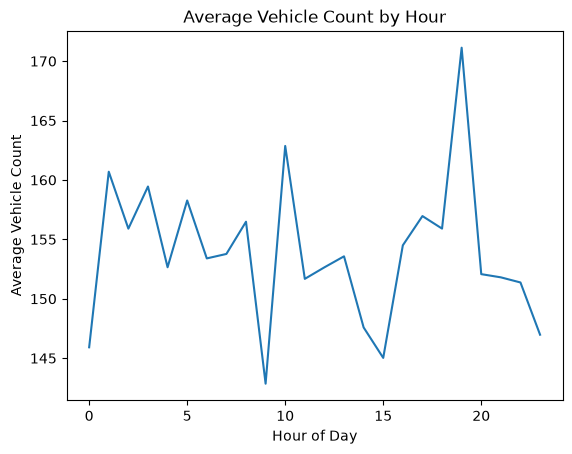

In [33]:
df.groupby("Hour")["Vehicle_Count"].mean().plot(kind="line")

plt.xlabel("Hour of Day")
plt.ylabel("Average Vehicle Count")
plt.title("Average Vehicle Count by Hour")

plt.show()

In [34]:
df["Day"] = df["Timestamp"].dt.day_name()
df[["Timestamp", "Day"]].head(10)

,Timestamp,Day
0,2024-03-01 00:00:00,Friday
1,2024-03-01 00:05:00,Friday
2,2024-03-01 00:10:00,Friday
3,2024-03-01 00:15:00,Friday
4,2024-03-01 00:20:00,Friday
5,2024-03-01 00:25:00,Friday
6,2024-03-01 00:30:00,Friday
7,2024-03-01 00:35:00,Friday
8,2024-03-01 00:40:00,Friday
9,2024-03-01 00:45:00,Friday


In [35]:
df.groupby("Day")["Vehicle_Count"].mean()

Day
Friday       153.707176
Monday       150.758824
Saturday     155.295139
Sunday       155.517361
Thursday     154.027778
Tuesday      157.270833
Wednesday    150.064236
Name: Vehicle_Count, dtype: float64

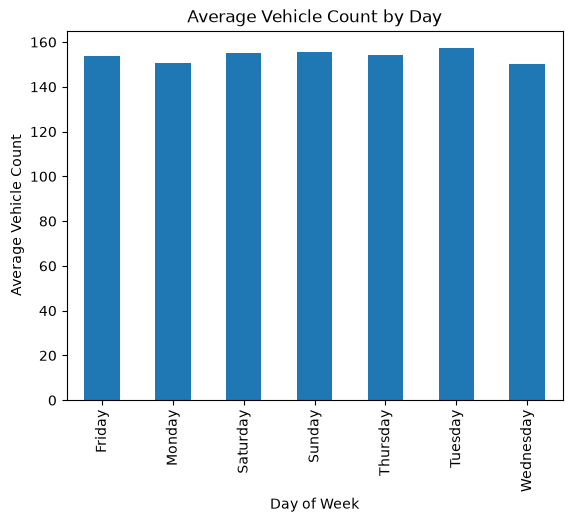

In [36]:
df.groupby("Day")["Vehicle_Count"].mean().plot(kind="bar")

plt.xlabel("Day of Week")
plt.ylabel("Average Vehicle Count")
plt.title("Average Vehicle Count by Day")

plt.show()

In [37]:
df["Traffic_Condition"].value_counts(normalize=True) * 100

Traffic_Condition
High      63.32
Medium    29.50
Low        7.18
Name: proportion, dtype: float64

## 3. Feature Engineering and Preprocessing

In [38]:
df.dtypes

Timestamp                 datetime64[us]
Latitude                         float64
Longitude                        float64
Vehicle_Count                      int64
Traffic_Speed_kmh                float64
Road_Occupancy_%                 float64
Traffic_Light_State                  str
Weather_Condition                    str
Accident_Report                    int64
Sentiment_Score                  float64
Ride_Sharing_Demand                int64
Parking_Availability               int64
Emission_Levels_g_km             float64
Energy_Consumption_L_h           float64
Traffic_Condition                    str
Hour                               int32
Day                                  str
dtype: object

In [39]:
df["Traffic_Light_State"].unique()


<ArrowStringArray>
['Yellow', 'Green', 'Red']
Length: 3, dtype: str

In [40]:
df["Weather_Condition"].unique()

<ArrowStringArray>
['Clear', 'Rain', 'Fog', 'Snow']
Length: 4, dtype: str

In [41]:
df["Day"].unique()

<ArrowStringArray>
['Friday', 'Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday']
Length: 7, dtype: str

In [42]:
df = pd.get_dummies(
    df,
    columns=["Traffic_Light_State", "Weather_Condition", "Day"],
    drop_first=True
)
df.head()

,Timestamp,Latitude,Longitude,Vehicle_Count,Traffic_Speed_kmh,Road_Occupancy_%,Accident_Report,Sentiment_Score,Ride_Sharing_Demand,Parking_Availability,...,Traffic_Light_State_Yellow,Weather_Condition_Fog,Weather_Condition_Rain,Weather_Condition_Snow,Day_Monday,Day_Saturday,Day_Sunday,Day_Thursday,Day_Tuesday,Day_Wednesday
0,2024-03-01 00:00:00,40.842275,-73.703149,205,49.893435,82.652780,0,-0.609199,2,45,...,True,False,False,False,False,False,False,False,False,False
1,2024-03-01 00:05:00,40.831119,-73.987354,202,22.383965,45.829298,0,0.965442,16,1,...,False,False,False,False,False,False,False,False,False,False
2,2024-03-01 00:10:00,40.819549,-73.732462,252,46.889699,82.772465,0,0.289660,16,49,...,False,False,True,False,False,False,False,False,False,False
3,2024-03-01 00:15:00,40.725849,-73.980134,37,5.730536,37.695567,0,-0.271965,66,10,...,False,True,False,False,False,False,False,False,False,False
4,2024-03-01 00:20:00,40.813265,-73.961631,64,61.348034,22.313358,0,-0.797606,3,5,...,False,False,False,True,False,False,False,False,False,False


In [43]:
df.dtypes

Timestamp                     datetime64[us]
Latitude                             float64
Longitude                            float64
Vehicle_Count                          int64
Traffic_Speed_kmh                    float64
Road_Occupancy_%                     float64
Accident_Report                        int64
Sentiment_Score                      float64
Ride_Sharing_Demand                    int64
Parking_Availability                   int64
Emission_Levels_g_km                 float64
Energy_Consumption_L_h               float64
Traffic_Condition                        str
Hour                                   int32
Traffic_Light_State_Red                 bool
Traffic_Light_State_Yellow              bool
Weather_Condition_Fog                   bool
Weather_Condition_Rain                  bool
Weather_Condition_Snow                  bool
Day_Monday                              bool
Day_Saturday                            bool
Day_Sunday                              bool
Day_Thursd

## 4. Preparing Data for Machine Learning

In [44]:
X = df.drop("Traffic_Condition", axis=1)
y = df["Traffic_Condition"]

In [45]:
X.shape


(5000, 24)

In [46]:
y.shape

(5000,)

In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [48]:
X_train.shape
X_test.shape

(1000, 24)

In [49]:
X.dtypes

Timestamp                     datetime64[us]
Latitude                             float64
Longitude                            float64
Vehicle_Count                          int64
Traffic_Speed_kmh                    float64
Road_Occupancy_%                     float64
Accident_Report                        int64
Sentiment_Score                      float64
Ride_Sharing_Demand                    int64
Parking_Availability                   int64
Emission_Levels_g_km                 float64
Energy_Consumption_L_h               float64
Hour                                   int32
Traffic_Light_State_Red                 bool
Traffic_Light_State_Yellow              bool
Weather_Condition_Fog                   bool
Weather_Condition_Rain                  bool
Weather_Condition_Snow                  bool
Day_Monday                              bool
Day_Saturday                            bool
Day_Sunday                              bool
Day_Thursday                            bool
Day_Tuesda

In [50]:
X = X.drop("Timestamp", axis=1)

In [51]:
X.shape

(5000, 23)

In [52]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [53]:
X_train.shape


(4000, 23)

In [54]:
X_test.shape

(1000, 23)

## 5. Model Training and Comparison

In [55]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [56]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [57]:
y_pred = model.predict(X_test_scaled)
y_pred[:10]

array(['Medium', 'High', 'Medium', 'Medium', 'High', 'High', 'Medium',
       'High', 'High', 'High'], dtype=object)

In [58]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.762


In [59]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        High       0.82      0.86      0.84       633
         Low       0.70      0.72      0.71        60
      Medium       0.62      0.56      0.59       307

    accuracy                           0.76      1000
   macro avg       0.72      0.71      0.72      1000
weighted avg       0.76      0.76      0.76      1000



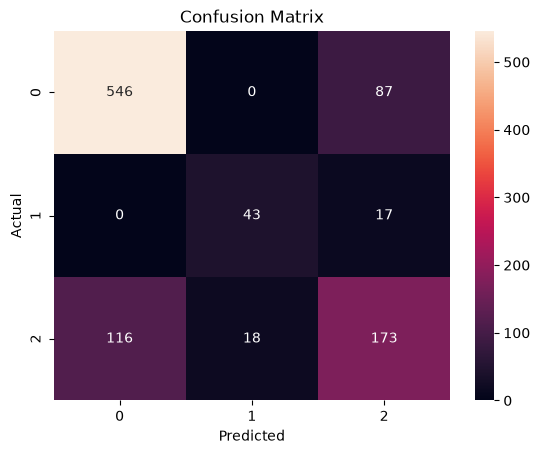

In [60]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [61]:
print("Model: Logistic Regression")
print("Accuracy:", accuracy)

Model: Logistic Regression
Accuracy: 0.762


In [62]:
from sklearn.tree import DecisionTreeClassifier

model_dt = DecisionTreeClassifier(random_state=42)

model_dt.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [63]:
y_pred_dt = model_dt.predict(X_test)

In [64]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", accuracy_dt)

Decision Tree Accuracy: 0.999


In [65]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

        High       1.00      1.00      1.00       633
         Low       1.00      0.98      0.99        60
      Medium       1.00      1.00      1.00       307

    accuracy                           1.00      1000
   macro avg       1.00      0.99      1.00      1000
weighted avg       1.00      1.00      1.00      1000



In [66]:
print("Training Accuracy:", model_dt.score(X_train, y_train))
print("Testing Accuracy:", model_dt.score(X_test, y_test))

Training Accuracy: 1.0
Testing Accuracy: 0.999


In [67]:
feature_importance = pd.Series(
    model_dt.feature_importances_,
    index=X_train.columns
)

print(feature_importance.sort_values(ascending=False))

Traffic_Speed_kmh             0.311836
Vehicle_Count                 0.292871
Road_Occupancy_%              0.270377
Accident_Report               0.124916
Latitude                      0.000000
Longitude                     0.000000
Sentiment_Score               0.000000
Ride_Sharing_Demand           0.000000
Parking_Availability          0.000000
Emission_Levels_g_km          0.000000
Energy_Consumption_L_h        0.000000
Hour                          0.000000
Traffic_Light_State_Red       0.000000
Traffic_Light_State_Yellow    0.000000
Weather_Condition_Fog         0.000000
Weather_Condition_Rain        0.000000
Weather_Condition_Snow        0.000000
Day_Monday                    0.000000
Day_Saturday                  0.000000
Day_Sunday                    0.000000
Day_Thursday                  0.000000
Day_Tuesday                   0.000000
Day_Wednesday                 0.000000
dtype: float64


In [68]:
pd.crosstab(pd.cut(df["Traffic_Speed_kmh"],bins=5),df["Traffic_Condition"])

Traffic_Condition,High,Low,Medium
Traffic_Speed_kmh,,,
"(4.928, 20.002]",1031,0,0
"(20.002, 35.001]",531,0,478
"(35.001, 50.0]",545,84,373
"(50.0, 64.999]",511,143,318
"(64.999, 79.998]",548,132,306


In [69]:
pd.crosstab(pd.cut(df["Vehicle_Count"],bins=5),df["Traffic_Condition"])

Traffic_Condition,High,Low,Medium
Vehicle_Count,,,
"(9.711, 67.8]",454,240,332
"(67.8, 125.6]",430,119,424
"(125.6, 183.4]",437,0,550
"(183.4, 241.2]",868,0,169
"(241.2, 299.0]",977,0,0


In [70]:
pd.crosstab(pd.cut(df["Road_Occupancy_%"],bins=5),df["Traffic_Condition"])

Traffic_Condition,High,Low,Medium
Road_Occupancy_%,,,
"(9.915, 28.004]",526,174,325
"(28.004, 46.003]",528,149,316
"(46.003, 64.002]",534,36,423
"(64.002, 82.001]",581,0,411
"(82.001, 100.0]",997,0,0


In [71]:
pd.crosstab(pd.cut(df["Accident_Report"],bins=5),df["Traffic_Condition"])

Traffic_Condition,High,Low,Medium
Accident_Report,,,
"(-0.001, 0.2]",2686,359,1475
"(0.8, 1.0]",480,0,0


In [72]:
df.groupby("Traffic_Condition")[["Vehicle_Count","Traffic_Speed_kmh","Road_Occupancy_%","Accident_Report"]].mean()

,Vehicle_Count,Traffic_Speed_kmh,Road_Occupancy_%,Accident_Report
Traffic_Condition,,,,
High,182.492419,37.865941,60.679654,0.151611
Low,53.389972,59.875717,29.536599,0.000000
Medium,117.063051,46.899342,48.153600,0.000000


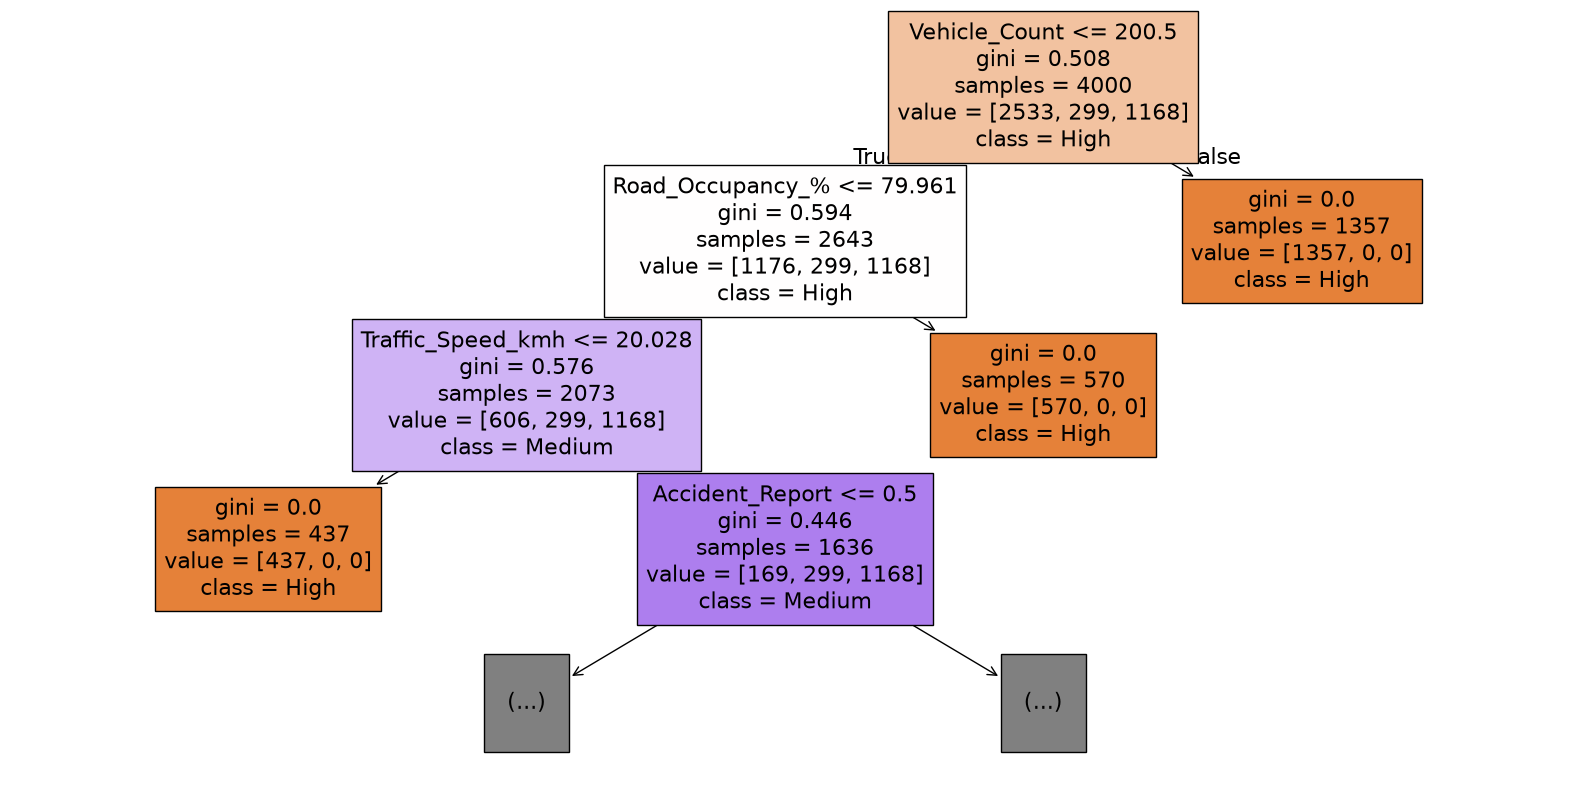

In [73]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))

plot_tree(
    model_dt,
    feature_names=X_train.columns,
    class_names=model_dt.classes_,
    filled=True,
    max_depth=3
)

plt.show()

In [74]:
model_dt2 = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

model_dt2.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

In [75]:
y_pred_dt2 = model_dt2.predict(X_test)

accuracy_dt2 = accuracy_score(y_test, y_pred_dt2)

print("Decision Tree Accuracy:", accuracy_dt2)

Decision Tree Accuracy: 0.94


In [76]:
print(classification_report(y_test, y_pred_dt2))


              precision    recall  f1-score   support

        High       1.00      1.00      1.00       633
         Low       0.00      0.00      0.00        60
      Medium       0.84      1.00      0.91       307

    accuracy                           0.94      1000
   macro avg       0.61      0.67      0.64      1000
weighted avg       0.89      0.94      0.91      1000



C:\Users\ARYAN RASTOGI\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ARYAN RASTOGI\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ARYAN RASTOGI\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packag

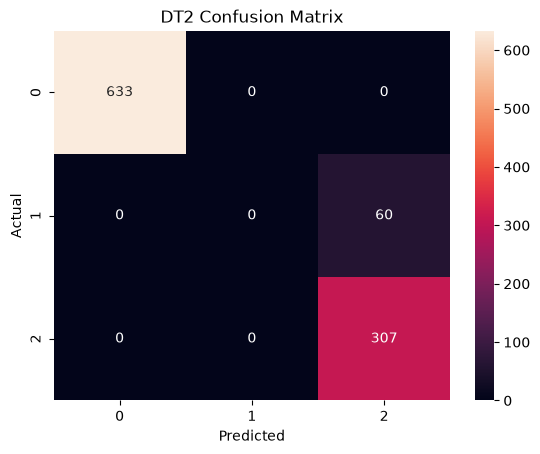

In [77]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_dt2)

sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("DT2 Confusion Matrix")
plt.show()

## 6. Investigating Feature Importance

In [78]:
X_no_top = X.drop([
    "Vehicle_Count",
    "Traffic_Speed_kmh",
    "Road_Occupancy_%",
    "Accident_Report"
], axis=1)

In [79]:
from sklearn.model_selection import train_test_split

# Split the new dataset
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_no_top,
    y,
    test_size=0.2,
    random_state=42
)

# Train Decision Tree
model_dt3 = DecisionTreeClassifier(random_state=42)
model_dt3.fit(X_train2, y_train2)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [80]:
y_pred_dt3 = model_dt3.predict(X_test2)

accuracy_dt3 = accuracy_score(y_test2, y_pred_dt3)

print("DT3 Accuracy:", accuracy_dt3)

DT3 Accuracy: 0.511


In [81]:
feature_importance_dt3 = pd.Series(
    model_dt3.feature_importances_,
    index=X_train2.columns
)

print(feature_importance_dt3.sort_values(ascending=False))

Latitude                      0.153282
Sentiment_Score               0.120393
Energy_Consumption_L_h        0.118324
Emission_Levels_g_km          0.107845
Ride_Sharing_Demand           0.104514
Longitude                     0.102982
Parking_Availability          0.086895
Hour                          0.082376
Traffic_Light_State_Red       0.016120
Traffic_Light_State_Yellow    0.015183
Day_Sunday                    0.014206
Weather_Condition_Snow        0.013659
Day_Saturday                  0.012456
Day_Tuesday                   0.011931
Day_Wednesday                 0.010119
Weather_Condition_Fog         0.009870
Day_Monday                    0.007390
Day_Thursday                  0.006337
Weather_Condition_Rain        0.006118
dtype: float64


In [82]:
print("Unique Latitudes:", df["Latitude"].nunique())
print("Unique Longitudes:", df["Longitude"].nunique())

Unique Latitudes: 5000
Unique Longitudes: 5000


In [83]:
df.groupby("Traffic_Condition")[["Latitude","Longitude"]].mean()

,Latitude,Longitude
Traffic_Condition,,
High,40.749501,-73.847174
Low,40.748298,-73.857671
Medium,40.750283,-73.845499


In [84]:
print(df[["Latitude","Longitude"]].describe())

          Latitude    Longitude
count  5000.000000  5000.000000
mean     40.749645   -73.847433
std       0.086123     0.086204
min      40.600016   -73.999987
25%      40.675403   -73.920281
50%      40.748875   -73.846058
75%      40.824735   -73.771685
max      40.899972   -73.700159


In [85]:
df.groupby("Traffic_Condition")[
    ["Vehicle_Count", "Traffic_Speed_kmh", "Road_Occupancy_%", "Accident_Report"]
].agg(["min", "max", "mean"])

Vehicle_Count                  Traffic_Speed_kmh             \
                            min  max        mean               min        max   
Traffic_Condition                                                               
High                         10  299  182.492419          5.002789  79.984448   
Low                          10  100   53.389972         40.625270  79.968768   
Medium                       10  200  117.063051         20.088544  79.997556   

                             Road_Occupancy_%                        \
                        mean              min        max       mean   
Traffic_Condition                                                     
High               37.865941        10.005031  99.999729  60.679654   
Low                59.875717        10.076556  49.632398  29.536599   
Medium             46.899342        10.089653  79.949792  48.153600   

                  Accident_Report                
                              min max      mean  
Traffic_Condition                                
High                            0   1  0.151611  
Low                             0   0  0.000000  
Medium                          0   0  0.000000

## 7. Random Forest Model

In [86]:
from sklearn.ensemble import RandomForestClassifier
model_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [87]:
model_rf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [88]:
y_pred_rf=model_rf.predict(X_test)

In [89]:
from sklearn.metrics import accuracy_score
accuracy_rf= accuracy_score(y_test,y_pred_rf)
print(accuracy_rf)

0.998


In [90]:
print(classification_report(y_test,y_pred_rf))

              precision    recall  f1-score   support

        High       1.00      1.00      1.00       633
         Low       1.00      0.97      0.98        60
      Medium       0.99      1.00      1.00       307

    accuracy                           1.00      1000
   macro avg       1.00      0.99      0.99      1000
weighted avg       1.00      1.00      1.00      1000



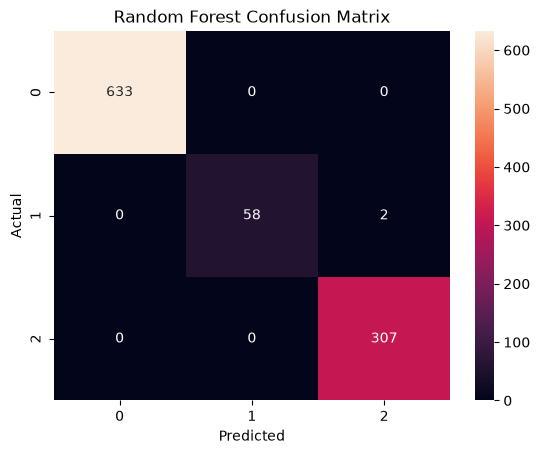

In [91]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_rf, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [92]:
feature_importance_rf = pd.Series(
    model_rf.feature_importances_,
    index=X_train.columns
)

print(feature_importance_rf.sort_values(ascending=False))

Vehicle_Count                 0.330398
Road_Occupancy_%              0.218060
Traffic_Speed_kmh             0.198960
Accident_Report               0.067589
Longitude                     0.021794
Sentiment_Score               0.021366
Energy_Consumption_L_h        0.021233
Latitude                      0.020749
Emission_Levels_g_km          0.020447
Ride_Sharing_Demand           0.018564
Parking_Availability          0.017749
Hour                          0.015270
Traffic_Light_State_Yellow    0.003198
Weather_Condition_Snow        0.003065
Traffic_Light_State_Red       0.002928
Weather_Condition_Rain        0.002773
Weather_Condition_Fog         0.002661
Day_Saturday                  0.002470
Day_Monday                    0.002343
Day_Sunday                    0.002321
Day_Wednesday                 0.002190
Day_Thursday                  0.002126
Day_Tuesday                   0.001748
dtype: float64


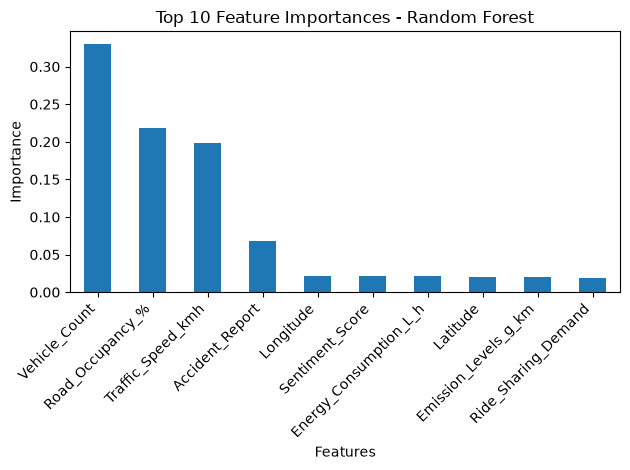

In [93]:
feature_importance_rf.sort_values(ascending=False).head(10).plot(
    kind="bar"
)

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Top 10 Feature Importances - Random Forest")
plt.xticks(rotation=45,ha="right")
plt.tight_layout()
plt.show()

In [94]:
models = {
    "Logistic Regression": 0.762,
    "Decision Tree": 0.999,
    "Decision Tree (Limited Depth)": 0.94,
    "Random Forest": 0.998
}

for model_name, accuracy in models.items():
    print(model_name, ":", accuracy)

Logistic Regression : 0.762
Decision Tree : 0.999
Decision Tree (Limited Depth) : 0.94
Random Forest : 0.998


In [95]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    model_rf,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross-validation scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

Cross-validation scores: [0.997 0.996 0.999 0.996 0.997]
Mean CV Accuracy: 0.9970000000000001


In [96]:
features_to_remove = [
    "Vehicle_Count",
    "Road_Occupancy_%",
    "Traffic_Speed_kmh",
    "Accident_Report"
]

X_reduced = X.drop(features_to_remove, axis=1)

X_train_reduced, X_test_reduced, y_train_reduced, y_test_reduced = train_test_split(
    X_reduced,
    y,
    test_size=0.2,
    random_state=42
)

In [97]:
model_rf_reduced = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model_rf_reduced.fit(X_train_reduced, y_train_reduced)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [98]:
y_pred_rf_reduced = model_rf_reduced.predict(X_test_reduced)

In [99]:
accuracy_rf_reduced = accuracy_score(
    y_test_reduced,
    y_pred_rf_reduced
)

print("Reduced Random Forest Accuracy:", accuracy_rf_reduced)

Reduced Random Forest Accuracy: 0.63


In [100]:
from sklearn.metrics import classification_report

print(classification_report(y_test_reduced, y_pred_rf_reduced))

              precision    recall  f1-score   support

        High       0.63      0.98      0.77       633
         Low       0.00      0.00      0.00        60
      Medium       0.41      0.02      0.04       307

    accuracy                           0.63      1000
   macro avg       0.35      0.34      0.27      1000
weighted avg       0.53      0.63      0.50      1000



C:\Users\ARYAN RASTOGI\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ARYAN RASTOGI\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\ARYAN RASTOGI\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packag

In [101]:
model_rf_balanced = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

model_rf_balanced.fit(X_train, y_train)

y_pred_rf_balanced = model_rf_balanced.predict(X_test)

In [102]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf_balanced))

              precision    recall  f1-score   support

        High       1.00      1.00      1.00       633
         Low       1.00      0.98      0.99        60
      Medium       1.00      1.00      1.00       307

    accuracy                           1.00      1000
   macro avg       1.00      0.99      1.00      1000
weighted avg       1.00      1.00      1.00      1000



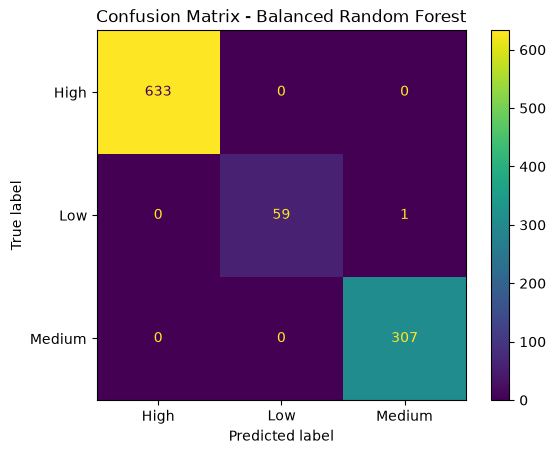

In [103]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_rf_balanced)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model_rf_balanced.classes_
)

disp.plot()
plt.title("Confusion Matrix - Balanced Random Forest")
plt.show()

In [104]:
from sklearn.model_selection import cross_val_score

cv_scores_balanced = cross_val_score(
    model_rf_balanced,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Cross-validation scores:", cv_scores_balanced)
print("Mean CV Accuracy:", cv_scores_balanced.mean())

Cross-validation scores: [0.999 0.998 1.    1.    0.997]
Mean CV Accuracy: 0.9987999999999999


In [105]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

baseline_model = DummyClassifier(strategy="most_frequent")

baseline_model.fit(X_train, y_train)

y_pred_baseline = baseline_model.predict(X_test)

baseline_accuracy = accuracy_score(y_test, y_pred_baseline)

print("Baseline Accuracy:", baseline_accuracy)

Baseline Accuracy: 0.633


## 8. Time-Based Evaluation

In [106]:
print("Start:", df["Timestamp"].min())
print("End:", df["Timestamp"].max())
print("Chronologically sorted:", df["Timestamp"].is_monotonic_increasing)

Start: 2024-03-01 00:00:00
End: 2024-03-18 08:35:00
Chronologically sorted: True


In [107]:
print(df["Timestamp"].dt.date.value_counts().sort_index())

Timestamp
2024-03-01    288
2024-03-02    288
2024-03-03    288
2024-03-04    288
2024-03-05    288
2024-03-06    288
2024-03-07    288
2024-03-08    288
2024-03-09    288
2024-03-10    288
2024-03-11    288
2024-03-12    288
2024-03-13    288
2024-03-14    288
2024-03-15    288
2024-03-16    288
2024-03-17    288
2024-03-18    104
Name: count, dtype: int64


In [108]:
train_data = df[df["Timestamp"].dt.date < pd.to_datetime("2024-03-15").date()]
test_data = df[df["Timestamp"].dt.date >= pd.to_datetime("2024-03-15").date()]
print("Training rows:", len(train_data))
print("Testing rows:", len(test_data))

Training rows: 4032
Testing rows: 968


In [109]:
X_train_time = train_data.drop(["Traffic_Condition", "Timestamp"], axis=1)
y_train_time = train_data["Traffic_Condition"]

X_test_time = test_data.drop(["Traffic_Condition", "Timestamp"], axis=1)
y_test_time = test_data["Traffic_Condition"]

In [110]:
print("X_train:", X_train_time.shape)
print("X_test:", X_test_time.shape)
print("y_train:", y_train_time.shape)
print("y_test:", y_test_time.shape)

X_train: (4032, 23)
X_test: (968, 23)
y_train: (4032,)
y_test: (968,)


In [111]:
model_rf_time = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

model_rf_time.fit(X_train_time, y_train_time)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

In [112]:
y_pred_rf_time = model_rf_time.predict(X_test_time)
print("prediction completed")

prediction completed


In [113]:
from sklearn.metrics import accuracy_score, classification_report

accuracy_time = accuracy_score(y_test_time, y_pred_rf_time)

print("Time-Based Test Accuracy:", accuracy_time)
print("\nClassification Report:")
print(classification_report(y_test_time, y_pred_rf_time))

Time-Based Test Accuracy: 0.9979338842975206

Classification Report:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00       610
         Low       1.00      0.97      0.99        70
      Medium       0.99      1.00      1.00       288

    accuracy                           1.00       968
   macro avg       1.00      0.99      0.99       968
weighted avg       1.00      1.00      1.00       968



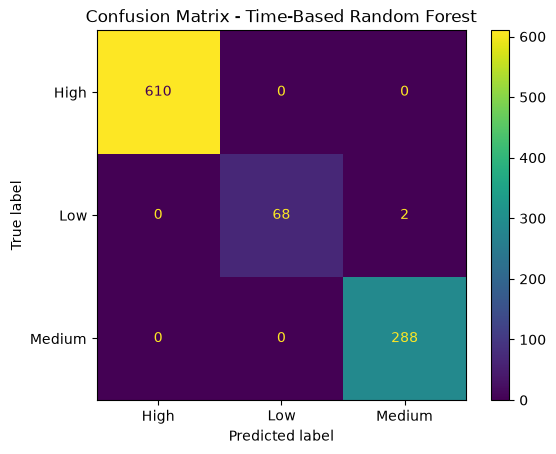

In [114]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_time = confusion_matrix(y_test_time, y_pred_rf_time)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_time,
    display_labels=model_rf_time.classes_
)

disp.plot()
plt.title("Confusion Matrix - Time-Based Random Forest")
plt.show()

In [115]:
feature_importance_time = pd.Series(
    model_rf_time.feature_importances_,
    index=X_train_time.columns
)

print(feature_importance_time.sort_values(ascending=False))

Vehicle_Count                 0.362584
Road_Occupancy_%              0.236702
Traffic_Speed_kmh             0.191012
Accident_Report               0.042261
Longitude                     0.020945
Sentiment_Score               0.019474
Latitude                      0.019326
Emission_Levels_g_km          0.018943
Energy_Consumption_L_h        0.018518
Ride_Sharing_Demand           0.016883
Parking_Availability          0.016016
Hour                          0.013318
Traffic_Light_State_Yellow    0.002676
Weather_Condition_Snow        0.002466
Traffic_Light_State_Red       0.002463
Day_Sunday                    0.002235
Day_Thursday                  0.002139
Weather_Condition_Fog         0.002125
Weather_Condition_Rain        0.002121
Day_Saturday                  0.002091
Day_Monday                    0.002013
Day_Wednesday                 0.001892
Day_Tuesday                   0.001796
dtype: float64


## 9. Final Model Comparison

In [116]:
results_final = {
    "Model": [
        "Baseline",
        "Logistic Regression",
        "Decision Tree",
        "Limited Depth Decision Tree",
        "Random Forest",
        "Balanced Random Forest",
        "Time-Based Balanced Random Forest"
    ],
    "Accuracy": [
        0.633,
        0.762,
        0.999,
        0.940,
        0.998,
        1.000,
        0.998
    ]
}

results_final_df = pd.DataFrame(results_final)

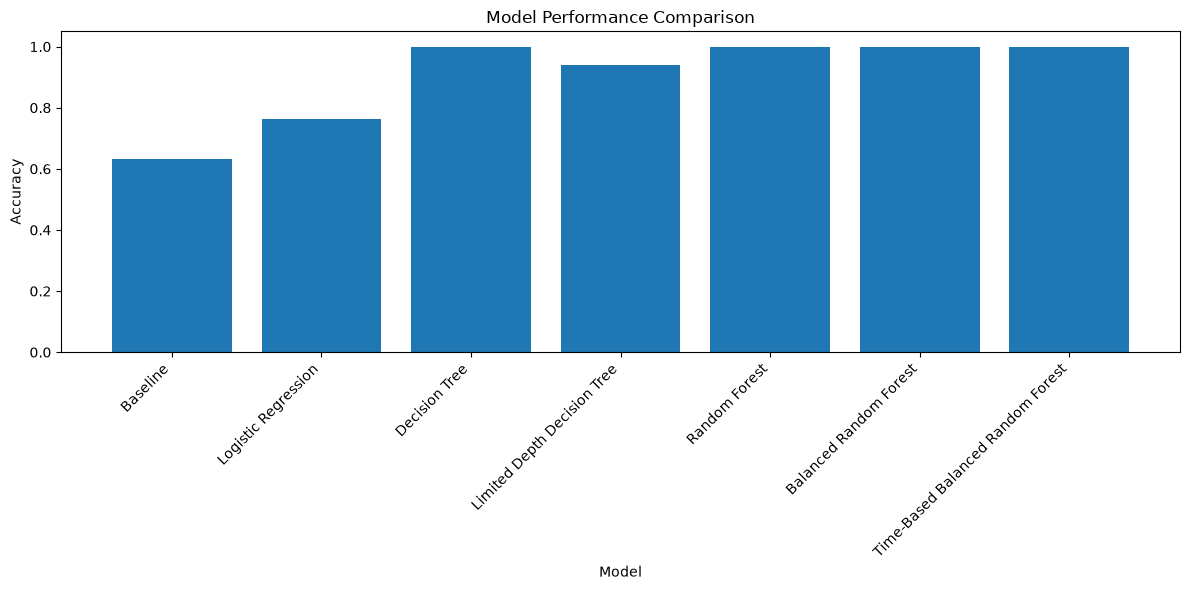

In [117]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.bar(
    results_final_df["Model"],
    results_final_df["Accuracy"]
)

plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.title("Model Performance Comparison")

plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1.05)

plt.tight_layout()
plt.show()

In [118]:
import joblib
joblib.dump(model_rf_time,"traffic_congestion.model.pkl")
print("model saved succesfully")

model saved succesfully


In [119]:
joblib.dump(X_train_time.columns.tolist(),"model_features.pkl")
print("feature list saved successfully")

feature list saved successfully


## 10. Example Prediction

In [120]:
for feature in X_train_time.columns:
    print(feature)

Latitude
Longitude
Vehicle_Count
Traffic_Speed_kmh
Road_Occupancy_%
Accident_Report
Sentiment_Score
Ride_Sharing_Demand
Parking_Availability
Emission_Levels_g_km
Energy_Consumption_L_h
Hour
Traffic_Light_State_Red
Traffic_Light_State_Yellow
Weather_Condition_Fog
Weather_Condition_Rain
Weather_Condition_Snow
Day_Monday
Day_Saturday
Day_Sunday
Day_Thursday
Day_Tuesday
Day_Wednesday


In [121]:
new_data = pd.DataFrame([{
    "Latitude": 40.75,
    "Longitude": -73.85,
    "Vehicle_Count": 150,
    "Traffic_Speed_kmh": 35,
    "Road_Occupancy_%": 50,
    "Accident_Report": 0,
    "Sentiment_Score": 0.2,
    "Ride_Sharing_Demand": 50,
    "Parking_Availability": 40,
    "Emission_Levels_g_km": 150,
    "Energy_Consumption_L_h": 5,
    "Hour": 12,
    "Traffic_Light_State_Red": False,
    "Traffic_Light_State_Yellow": False,
    "Weather_Condition_Fog": False,
    "Weather_Condition_Rain": False,
    "Weather_Condition_Snow": False,
    "Day_Monday": False,
    "Day_Saturday": False,
    "Day_Sunday": False,
    "Day_Thursday": False,
    "Day_Tuesday": False,
    "Day_Wednesday": False
}])

print(new_data.to_string())

   Latitude  Longitude  Vehicle_Count  Traffic_Speed_kmh  Road_Occupancy_%  Accident_Report  Sentiment_Score  Ride_Sharing_Demand  Parking_Availability  Emission_Levels_g_km  Energy_Consumption_L_h  Hour  Traffic_Light_State_Red  Traffic_Light_State_Yellow  Weather_Condition_Fog  Weather_Condition_Rain  Weather_Condition_Snow  Day_Monday  Day_Saturday  Day_Sunday  Day_Thursday  Day_Tuesday  Day_Wednesday
0     40.75     -73.85            150                 35                50                0              0.2                   50                    40                   150                       5    12                    False                       False                  False                   False                   False       False         False       False         False        False          False


In [122]:
prediction = model_rf_time.predict(new_data)

print("Predicted Traffic Condition:", prediction[0])

Predicted Traffic Condition: Medium


In [123]:
prediction_proba = model_rf_time.predict_proba(new_data)

print( prediction_proba)

[[0.16 0.   0.84]]


In [124]:
print(model_rf_time.classes_)

['High' 'Low' 'Medium']


In [125]:
def predict_traffic(
    latitude,
    longitude,
    vehicle_count,
    speed,
    occupancy,
    accident,
    sentiment,
    ride_demand,
    parking,
    emissions,
    energy,
    hour,
    traffic_light,
    weather,
    day
):

    data = pd.DataFrame([{
        "Latitude": latitude,
        "Longitude": longitude,
        "Vehicle_Count": vehicle_count,
        "Traffic_Speed_kmh": speed,
        "Road_Occupancy_%": occupancy,
        "Accident_Report": accident,
        "Sentiment_Score": sentiment,
        "Ride_Sharing_Demand": ride_demand,
        "Parking_Availability": parking,
        "Emission_Levels_g_km": emissions,
        "Energy_Consumption_L_h": energy,
        "Hour": hour,
        "Traffic_Light_State_Red": traffic_light == "Red",
        "Traffic_Light_State_Yellow": traffic_light == "Yellow",
        "Weather_Condition_Fog": weather == "Fog",
        "Weather_Condition_Rain": weather == "Rain",
        "Weather_Condition_Snow": weather == "Snow",
        "Day_Monday": day == "Monday",
        "Day_Saturday": day == "Saturday",
        "Day_Sunday": day == "Sunday",
        "Day_Thursday": day == "Thursday",
        "Day_Tuesday": day == "Tuesday",
        "Day_Wednesday": day == "Wednesday"
    }])

    data = data[X_train_time.columns]

    prediction = model_rf_time.predict(data)[0]

    probabilities = model_rf_time.predict_proba(data)[0]

    class_probabilities = dict(
        zip(model_rf_time.classes_, probabilities)
    )

    return prediction, class_probabilities

In [126]:
predict_traffic(
    40.75, -73.85, 150, 35, 50, 0,
    0.2, 50, 40, 150, 5, 12,
    "Green", "Clear", "Tuesday"
)

('Medium',
 {'High': np.float64(0.17),
  'Low': np.float64(0.0),
  'Medium': np.float64(0.83)})

In [ ]:
result, probabilities = predict_traffic(
    40.75,
    -73.85,
    150,
    35,
    50,
    0,
    0.2,
    50,
    40,
    150,
    5,
    12,
    "Green",
    "Clear",
    "Tuesday"
)

print("Predicted Traffic Condition:", result)
print("probabilities:")
for class_name,probability in probabilities.items():
    print(f"{class_name}:{probability:.0%}")

Predicted Traffic Condition: Medium
probabilities:
High:17%
Low:0%
Medium:83%


In [128]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test_time, y_pred_rf_time))
print("Precision:", precision_score(y_test_time, y_pred_rf_time, average="weighted"))
print("Recall:", recall_score(y_test_time, y_pred_rf_time, average="weighted"))
print("F1 Score:", f1_score(y_test_time, y_pred_rf_time, average="weighted"))

Accuracy: 0.9979338842975206
Precision: 0.9979481333713308
Recall: 0.9979338842975206
F1 Score: 0.997922487039245


In [129]:
print("Macro F1 Score:", f1_score(
    y_test_time,
    y_pred_rf_time,
    average="macro"
))

Macro F1 Score: 0.9940156795881183


In [130]:
print("Macro Precision:", precision_score(
    y_test_time,
    y_pred_rf_time,
    average="macro"
))

print("Macro Recall:", recall_score(
    y_test_time,
    y_pred_rf_time,
    average="macro"
))

print("Macro F1:", f1_score(
    y_test_time,
    y_pred_rf_time,
    average="macro"
))

Macro Precision: 0.9977011494252874
Macro Recall: 0.9904761904761905
Macro F1: 0.9940156795881183


In [131]:
import joblib

joblib.dump(model_rf_time, "traffic_congestion_model.pkl")
joblib.dump(X_train_time.columns.tolist(), "model_features.pkl")

print("Final model and feature list saved successfully!")

Final model and feature list saved successfully!
